<br>
<center><img src='../Header_image/header_image.png' style="width:900px"></center>
<br>
<p style="font-size:30px; text-align:center;"><b>Session 9 — Seismic I: Synthetic Seismogram and 3D Visualization</b></p>

---

# 1. Introduction 

A synthetic seismogram is built from well-log data using three simple operations:

| Step | Mathematical operation | Result |
|------|----------------------|--------|
| **Depth → Time** | Integrate slowness (1/V) | Time-to-depth relationship (TDR) |
| **Impedance** | Multiply velocity × density | Acoustic impedance log *Z* |
| **Reflectivity** | Differentiate *Z* | Reflection-coefficient series *RC* |
| **Synthetic** | Convolve *RC* with a wavelet | Synthetic seismogram |

The integral tells us *where* a rock interval sits in two-way-time (TWT); the derivative tells us *what it looks like* seismically.

**Data used:** Penobscot L-30 well (offshore Nova Scotia) — sonic (DT) and density (RHOB) logs in LAS format.

<br>
<center><img src="./NB_images/offshore_well.png" style="width:850px"></center>
<br>

# 2. Setup — Libraries and Data

**Required libraries**
- `numpy` / `matplotlib` — numerical computing and plotting
- `lasio` — reading LAS (Log ASCII Standard) files ([docs](https://lasio.readthedocs.io/en/latest/))
- `segyio` — reading SEG-Y seismic files ([docs](https://github.com/equinor/segyio))
- `ipywidgets` — interactive sliders

Run the cell below once to check your working directory and available input files.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import lasio
import segyio
from ipywidgets import interact, widgets

%matplotlib inline
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Working directory:", os.getcwd())
print("\nInput files:")
for f in sorted(os.listdir('./Input')):
    print(" ", f)

Python : 3.12.12
NumPy  : 2.3.4
Working directory: c:\Users\u_ber\Downloads\Curso Python para Geociencias 2026\sovg\Session_9_Seismic_I

Input files:
  B-41.las
  F3_Dip_steered_median_subvolume_IL230-430_XL475-675_T1600-1800.sgy
  L-30.las
  PenobXL_1155.txt
  tops.txt


# 3. Loading the LAS File

We use `lasio.read()` to open the Penobscot L-30 LAS file.  
A `lasio.LASFile` object stores log curves, well metadata, and header information.

In [2]:
L30 = lasio.read('./Input/L-30.las')

print("=== Available curves ===")
print(L30.curves)
print("\nObject type:", type(L30))

=== Available curves ===
Mnemonic  Unit  Value  Description                                                    
--------  ----  -----  -----------                                                    
DEPTH:1   FT           1 Depth                                                        
CALD      IN           2 Caliper    Caliper - Density                                 
CALS      IN           3 Caliper    Caliper - Sonic                                   
DEPTH:2   FT           4 Depth                                                        
DRHO      G/CC         5 Drho       Delta Rho                                         
DT        US/F         6 Sonic      Delta-T                                           
GRD       GAPI         7 GammaRay   Gamma Ray - Density                               
GRS       GAPI         8 GammaRay   Gamma Ray - Sonic                                 
ILD       OHMM         9 DeepRes    Deep Induction Standard Processed Resistivity     
ILM       OHMM    

Convert the LAS object to a Pandas DataFrame for easy inspection.

In [3]:
L30DF = L30.df().reset_index()
L30DF.head(10)

,DEPTH:1,CALD,CALS,DEPTH:2,DRHO,DT,GRD,GRS,ILD,ILM,LL8,NPHILS,NPHISS,RHOB,SP
0,1140.0,NaN,NaN,1140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1140.5,NaN,NaN,1140.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1141.0,NaN,NaN,1141.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1141.5,NaN,NaN,1141.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1142.0,NaN,NaN,1142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1142.5,NaN,NaN,1142.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1143.0,NaN,NaN,1143.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1143.5,NaN,NaN,1143.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1144.0,NaN,NaN,1144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1144.5,NaN,NaN,1144.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 4. Helper Functions

### 4.1 Unit conversion — feet → metres

All depth and elevation values in the LAS header are stored in **feet**.  
We convert to SI units (metres) throughout this notebook.

In [4]:
def ft2m(item_in_feet):
    """Convert feet to metres.

    Accepts scalars or array-like inputs.

    Parameters
    ----------
    item_in_feet : float or array-like
        Value(s) in feet.

    Returns
    -------
    float or array-like
        Equivalent value(s) in metres.
    """
    try:
        return item_in_feet / 3.28084
    except TypeError:
        return float(item_in_feet) / 3.28084

### 4.2 Extract and convert log curves

| Variable | Source column | Conversion |
|----------|--------------|------------|
| `DEPTH` | `DEPTH:1` (ft) | → metres |
| `DT` | `DT` (μs/ft) | → μs/m (×3.28084) |
| `RHOB` | `RHOB` (g/cm³) | → kg/m³ (×1000) |
| `ILD` | `ILD` | no conversion |

In [5]:
DEPTH = ft2m(L30DF['DEPTH:1'])      # depth [m]
ILD   = L30DF['ILD']                # resistivity [Ω·m] — kept for reference
DT    = L30DF['DT'] * 3.28084       # slowness [μs/m]
RHOB  = L30DF['RHOB'] * 1000        # density [kg/m³]

print("Depth range : {:.1f} – {:.1f} m  ({:,} samples)".format(
      DEPTH.min(), DEPTH.max(), len(DEPTH)))
print("DT range    : {:.1f} – {:.1f} μs/m".format(DT.min(), DT.max()))
print("RHOB range  : {:.0f} – {:.0f} kg/m³".format(RHOB.min(), RHOB.max()))

Depth range : 347.5 – 4252.0 m  (25,621 samples)
DT range    : 130.2 – 653.8 μs/m
RHOB range  : 1584 – 2811 kg/m³


# 5. Shallow-Section Time Corrections

Because the sonic log only starts at ~350 m TVDss, we need to estimate the two-way
travel time (TWT) above the top of the log using replacement velocities.

**Velocity model above the log top**

```
Sea level (MSL)
│
├─── water column  →  V_water  = 1 480 m/s
│
├─── soft sediments (replacement interval, REPI)  →  V_repl = 1 600 m/s
│
└─── top of sonic log  (= LOGSS_TWT)
```

All references are extracted from the LAS well header (stored in feet).

In [6]:
# ── Well metadata ────────────────────────────────────────────────────────────
print("Well header:")
print(L30.well)

Well header:
Mnemonic  Unit  Value                               Description                      
--------  ----  -----                               -----------                      
STRT      FT    1140.0                              START DEPTH                      
STOP      FT    13950.0                             STOP DEPTH                       
STEP      FT    0.5                                 STEP VALUE                       
NULL            -999.0                              NULL VALUE                       
SRVC            SCH                                 Service Company/Logging company  
DATE            08/24/2011                          LAS file Creation Date           
WELL            PENOBSCOT L-30                      Well Name                        
COMP            SHELL CANADA RESOURCES LIMITED      Company                          
FLD             Wildcat                             Field                            
STATE           Nova Scotia Shelf        

In [7]:
# ── Extract well reference datums (all in feet from LAS header) ─────────────
KB     = L30.well['KB'].value    # Kelly Bushing elevation [ft]
WD     = L30.well['GL'].value    # Water depth below MSL [ft]  (GL = ground level/seabed)
LOGSS  = L30.well['STRT'].value  # Top of log below KB [ft]

print(f"Kelly Bushing   : {KB:.2f} ft  ({ft2m(KB):.2f} m)")
print(f"Water depth     : {WD:.2f} ft  ({ft2m(WD):.2f} m)")
print(f"Log start (KB)  : {LOGSS:.2f} ft  ({ft2m(LOGSS):.2f} m)")

Kelly Bushing   : 99.00 ft  (30.18 m)
Water depth     : -451.00 ft  (-137.46 m)
Log start (KB)  : 1140.00 ft  (347.47 m)


In [8]:
# ── Velocity constants ───────────────────────────────────────────────────────
water_vel = 1480   # sea-water velocity [m/s]
repl_vel  = 1600   # replacement velocity for soft sediments [m/s]

# TWT from surface to sea floor (via KB)
KB_TWT   = 2.0 * np.abs(ft2m(KB)) / water_vel
W_TWT    = 2.0 * ft2m(np.abs(WD)) / water_vel + KB_TWT

# Replacement interval: distance from sea floor to top of log
REPI     = ft2m(LOGSS) - ft2m(KB) + ft2m(WD)   # [m]
REPI_TWT = 2.0 * REPI / repl_vel

# TWT at the top of the sonic log
LOGSS_TWT = W_TWT + REPI_TWT

print("─" * 40)
print(f"KB TWT            : {KB_TWT:.4f} s")
print(f"Water TWT         : {W_TWT:.4f} s")
print(f"Replacement intv. : {REPI:.2f} m  →  {REPI_TWT:.4f} s")
print(f"Log-start TWT     : {LOGSS_TWT:.4f} s")
print("─" * 40)

────────────────────────────────────────
KB TWT            : 0.0408 s
Water TWT         : 0.2265 s
Replacement intv. : 179.83 m  →  0.2248 s
Log-start TWT     : 0.4513 s
────────────────────────────────────────


# 6. Log Quality Control — Despiking

Raw well logs often contain high-amplitude spikes (tool noise, cycle skipping, etc.).
`np.clip()` is unsuitable here because there is a systematic trend in the data.
Instead, we:

1. Compute a **rolling median** (edge-preserving smoother) in a window of ~2 m.
2. Flag samples where `|original − smooth| > threshold` as spikes.
3. Replace spikes by clamping to `smooth ± threshold`.

### 6.1 Rolling window utility

In [9]:
def rolling_window(a, window):
    """Efficient rolling window using stride tricks.

    Parameters
    ----------
    a : 1-D ndarray
    window : int  — window length

    Returns
    -------
    2-D ndarray of shape (n - window + 1, window)
    """
    shape   = a.shape[:-1] + (a.shape[-1] - window + 1, window)
    strides = a.strides + (a.strides[-1],)
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides)


def despike(curve, curve_sm, max_clip):
    """Replace spikes that exceed `max_clip` above/below the smoothed curve.

    Parameters
    ----------
    curve    : array-like  — original log values
    curve_sm : array-like  — smoothed version of the same log
    max_clip : float       — maximum allowed deviation from smooth

    Returns
    -------
    out : ndarray — despiked log (same length as input)
    """
    curve    = np.asarray(curve)
    curve_sm = np.asarray(curve_sm)
    spikes   = np.where(curve - curve_sm >  max_clip)[0]   # positive spikes
    spukes   = np.where(curve_sm - curve >  max_clip)[0]   # negative spikes
    out = np.copy(curve)
    out[spikes] = curve_sm[spikes] + max_clip
    out[spukes] = curve_sm[spukes] - max_clip
    return out

### 6.2 Despike RHOB (density log)

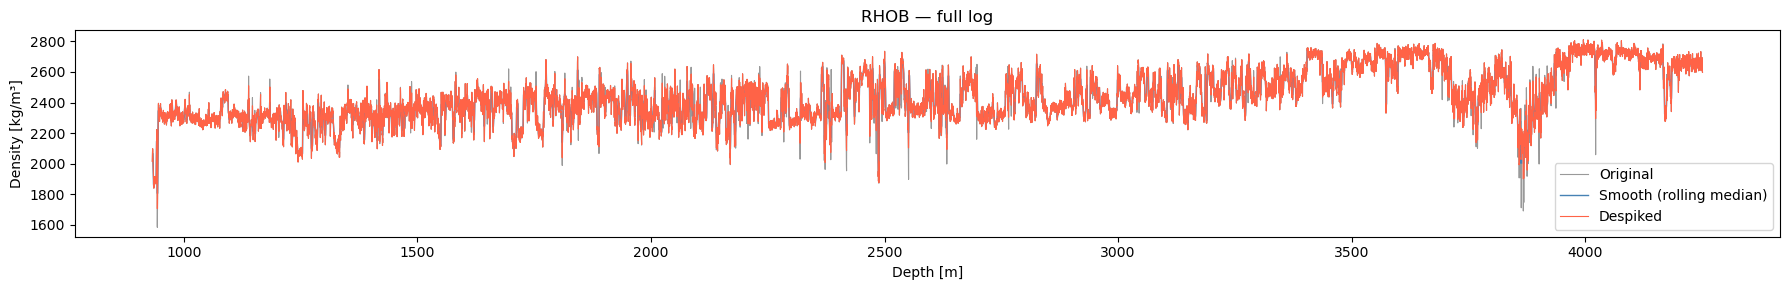

In [10]:
WINDOW = 13   # ~2 m at 0.1524 m/sample

# ── Smooth with rolling median ────────────────────────────────────────────────
RHOB_SM   = np.median(rolling_window(RHOB.to_numpy(), WINDOW), axis=-1)
RHOB_SM   = np.pad(RHOB_SM, WINDOW // 2, mode='edge')   # restore original length

# ── Despike ───────────────────────────────────────────────────────────────────
RHOB_DESP = despike(RHOB, RHOB_SM, max_clip=100)

# ── Diagnostic plot — full log ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 3))
ax.plot(DEPTH, RHOB,      'k', alpha=0.4, lw=0.8, label='Original')
ax.plot(DEPTH, RHOB_SM,   'steelblue', lw=1.0,   label='Smooth (rolling median)')
ax.plot(DEPTH, RHOB_DESP, 'tomato',    lw=0.8,   label='Despiked')
ax.set_xlabel('Depth [m]')
ax.set_ylabel('Density [kg/m³]')
ax.set_title('RHOB — full log')
ax.legend()
plt.tight_layout()
plt.show()

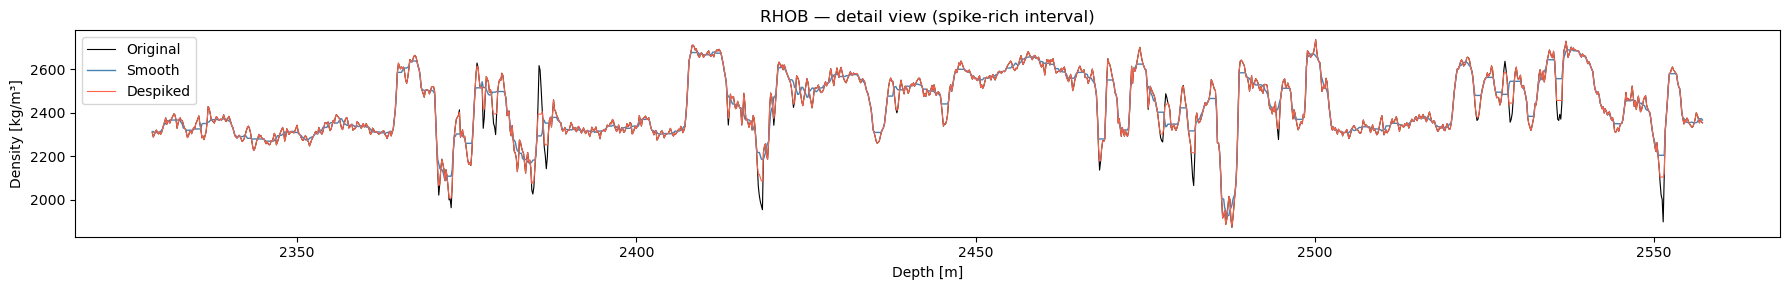

In [11]:
# ── Zoom into a spike-rich interval ──────────────────────────────────────────
START, END = 13000, 14500
fig, ax = plt.subplots(figsize=(18, 3))
ax.plot(DEPTH[START:END], RHOB[START:END],      'k',        lw=0.8, label='Original')
ax.plot(DEPTH[START:END], RHOB_SM[START:END],   'steelblue',lw=1.0, label='Smooth')
ax.plot(DEPTH[START:END], RHOB_DESP[START:END], 'tomato',   lw=0.8, label='Despiked')
ax.set_xlabel('Depth [m]')
ax.set_ylabel('Density [kg/m³]')
ax.set_title('RHOB — detail view (spike-rich interval)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Despike DT (sonic / slowness log)

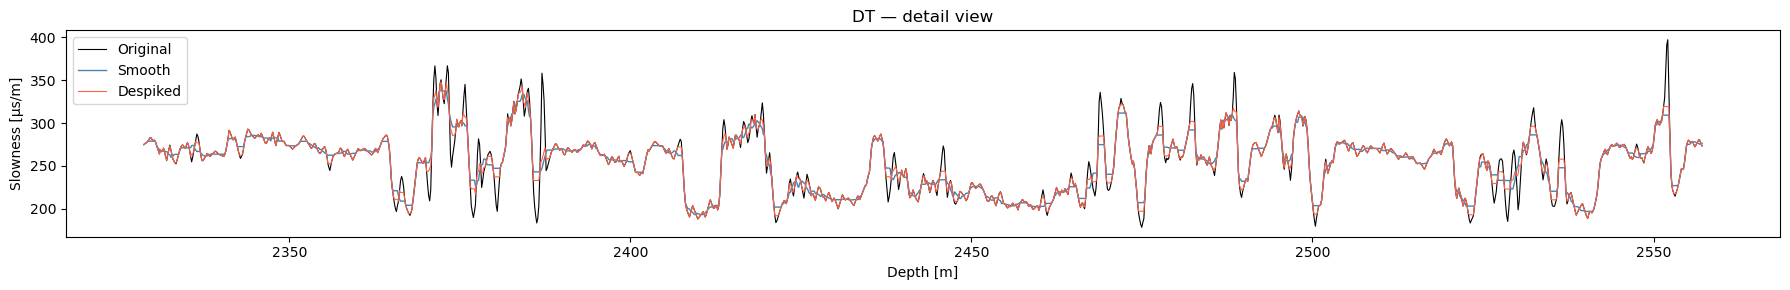

In [12]:
DT_SM   = np.median(rolling_window(DT.to_numpy(), WINDOW), axis=-1)
DT_SM   = np.pad(DT_SM, WINDOW // 2, mode='edge')
DT_DESP = despike(DT, DT_SM, max_clip=10)

START, END = 13000, 14500
fig, ax = plt.subplots(figsize=(18, 3))
ax.plot(DEPTH[START:END], DT[START:END],      'k',        lw=0.8, label='Original')
ax.plot(DEPTH[START:END], DT_SM[START:END],   'steelblue',lw=1.0, label='Smooth')
ax.plot(DEPTH[START:END], DT_DESP[START:END], 'tomato',   lw=0.8, label='Despiked')
ax.set_xlabel('Depth [m]')
ax.set_ylabel('Slowness [μs/m]')
ax.set_title('DT — detail view')
ax.legend()
plt.tight_layout()
plt.show()

# 7. Well-Tie Calculations

### 7.1 Time-to-depth relationship (TDR)

Integrating the scaled sonic log gives cumulative two-way travel time as a function of depth.

$$
t(z) = t_0 + 2 \int_{z_0}^{z} s(z')\, dz'
$$

where $s = \Delta t \times 10^{-6}$ is slowness in s/m and $\Delta z = 0.1524$ m (6-inch sample interval).

In [13]:
DT_SCALED = 0.1524 * np.nan_to_num(DT) / 1e6   # slowness [s/sample]
TCUM      = 2.0 * np.cumsum(DT_SCALED)            # cumulative TWT from log top [s]
TDR       = LOGSS_TWT + TCUM                      # absolute TWT [s]

print(f"TDR spans  {TDR.min():.4f} – {TDR.max():.4f} s TWT")
print(f"Log covers {DEPTH.min():.1f} – {DEPTH.max():.1f} m MD")

TDR spans  0.4513 – 2.8685 s TWT
Log covers 347.5 – 4252.0 m MD


### 7.2 Acoustic impedance

$$Z = V_P \times \rho = \frac{10^6}{\Delta t_{\text{desp}}} \times \rho_{\text{desp}}$$

In [14]:
Z = (1e6 / DT_DESP) * RHOB_DESP

print(f"Z range: {np.nanmin(Z):.2e} – {np.nanmax(Z):.2e}  kg/(m²·s)")

Z range: 3.72e+06 – 1.79e+07  kg/(m²·s)


### 7.3 Reflection coefficient series (depth domain)

$$RC_i = \frac{Z_{i+1} - Z_i}{Z_{i+1} + Z_i}$$

In [15]:
RC = (Z[1:] - Z[:-1]) / (Z[1:] + Z[:-1])
print(f"RC stats — min: {np.nanmin(RC):.4f}  max: {np.nanmax(RC):.4f}  "
      f"std: {np.nanstd(RC):.4f}  non-zero: {np.count_nonzero(RC):,}")

RC stats — min: -0.1235  max: 0.1407  std: 0.0120  non-zero: 25,539


### 7.4 Well tops

Load stratigraphic tops from a tab-delimited text file and convert their depths to TWT using the TDR.

In [16]:
def find_nearest(array, value):
    """Return the index of the element in `array` closest to `value`."""
    return (np.abs(np.asarray(array) - value)).argmin()


# ── Load tops from file ───────────────────────────────────────────────────────
tops = {}
with open('./Input/tops.txt') as f:
    for line in f:
        if not line.startswith('#'):
            parts = line.strip().split('\t')
            tops[parts[-1].replace('_', ' ')] = float(parts[1])

print("Tops loaded (depth [m]):")
for name, depth in tops.items():
    print(f"  {name:<25s}  {depth:.1f} m")

# ── Convert to TWT ────────────────────────────────────────────────────────────
tops_twt = {name: TDR[find_nearest(DEPTH, depth)] for name, depth in tops.items()}

print("\nTops in TWT [s]:")
for name, twt in tops_twt.items():
    print(f"  {name:<25s}  {twt:.4f} s")

Tops loaded (depth [m]):
  Wyandot                    867.2 m
  Dawson Canyon              984.5 m
  Logan Canyon               1136.9 m
  U Missisauga               2251.3 m
  Base O-Marker              2469.2 m
  L Missisauga               3190.6 m
  Abenaki                    3404.3 m
  Mid Baccaro                3485.1 m
  L Baccaro                  3964.5 m

Tops in TWT [s]:
  Wyandot                    0.9628 s
  Dawson Canyon              1.0501 s
  Logan Canyon               1.1753 s
  U Missisauga               1.9107 s
  Base O-Marker              2.0240 s
  L Missisauga               2.4023 s
  Abenaki                    2.5053 s
  Mid Baccaro                2.5391 s
  L Baccaro                  2.7534 s


# 8. Log Panel — Depth Domain

Four-panel figure showing the cascade from sonic log → cumulative TWT → impedance → reflectivity.

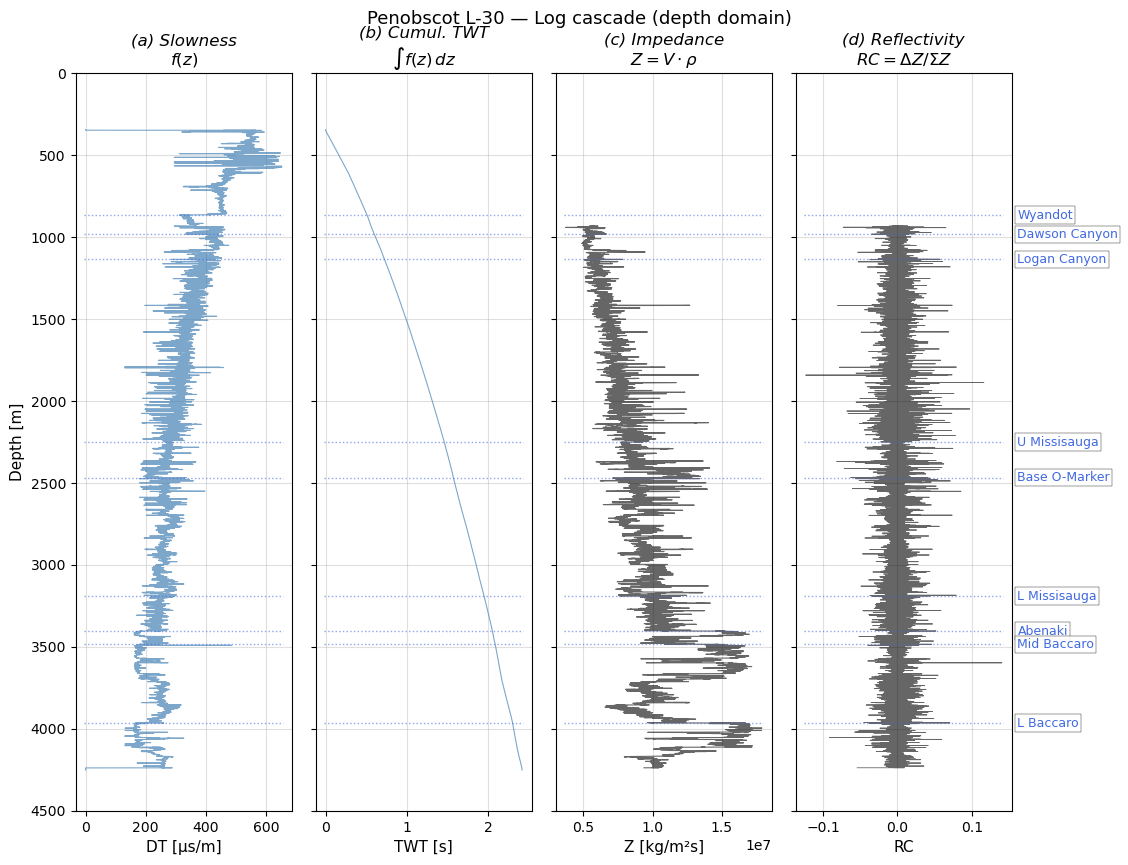

In [17]:
fig = plt.figure(figsize=(12, 9))
axes = [
    fig.add_axes([0.08, 0.08, 0.18, 0.82]),
    fig.add_axes([0.28, 0.08, 0.18, 0.82]),
    fig.add_axes([0.48, 0.08, 0.18, 0.82]),
    fig.add_axes([0.68, 0.08, 0.18, 0.82]),
]

# ── ax0: sonic log ────────────────────────────────────────────────────────────
axes[0].plot(DT, DEPTH, 'steelblue', alpha=0.7, lw=0.8)
axes[0].set_title('(a) Slowness\n$f(z)$', style='italic')
axes[0].set_ylabel('Depth [m]', fontsize=11)
axes[0].set_xlabel('DT [μs/m]', fontsize=11)
axes[0].set_ylim(0, 4500)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.4)

# ── ax1: cumulative TWT (integral) ───────────────────────────────────────────
axes[1].plot(TCUM, DEPTH, 'steelblue', alpha=0.7, lw=0.8)
axes[1].set_title('(b) Cumul. TWT\n$\\int f(z)\\,dz$', style='italic')
axes[1].set_xlabel('TWT [s]', fontsize=11)
axes[1].set_ylim(4500, 0)
axes[1].set_yticklabels([])
axes[1].grid(alpha=0.4)

# ── ax2: acoustic impedance ───────────────────────────────────────────────────
axes[2].plot(Z, DEPTH, 'k', alpha=0.6, lw=0.8)
axes[2].set_title('(c) Impedance\n$Z = V\\cdot\\rho$', style='italic')
axes[2].set_xlabel('Z [kg/m²s]', fontsize=11)
axes[2].set_ylim(4500, 0)
axes[2].set_yticklabels([])
axes[2].grid(alpha=0.4)

# ── ax3: reflectivity (derivative) ───────────────────────────────────────────
axes[3].plot(RC, DEPTH[:-1], 'k', alpha=0.6, lw=0.6)
axes[3].set_title('(d) Reflectivity\n$RC = \\Delta Z / \\Sigma Z$', style='italic')
axes[3].set_xlabel('RC', fontsize=11)
axes[3].set_ylim(4500, 0)
axes[3].set_yticklabels([])
axes[3].grid(alpha=0.4)

# ── annotate tops on all panels ───────────────────────────────────────────────
for ax in axes:
    for depth in tops.values():
        ax.axhline(y=depth, color='royalblue', lw=1, ls=':', alpha=0.6,
                   xmin=0.04, xmax=0.96)

# label tops on the last panel
for name, depth in tops.items():
    axes[3].text(x=axes[3].get_xlim()[1] * 1.05, y=depth, s=name,
                 fontsize=9, va='center', color='royalblue',
                 bbox=dict(facecolor='white', alpha=0.9, lw=0.3, pad=1.5))

fig.suptitle('Penobscot L-30 — Log cascade (depth domain)', y=0.97, fontsize=13)
plt.show()

# 9. Resampling Logs to the Time Domain

Seismic data is sampled in time. We interpolate the impedance log onto a regular time grid
using the TDR, then re-derive the reflection series at seismic sample rate.

In [18]:
dt_seis = 0.004   # seismic sample interval [s]
t_max   = 3.0     # maximum TWT [s]

t    = np.arange(0.0, t_max, dt_seis)            # regular time axis [s]
Z_t  = np.interp(x=t, xp=TDR, fp=Z)             # impedance resampled to time

# Re-derive RC in the time domain
RC_t = (Z_t[1:] - Z_t[:-1]) / (Z_t[1:] + Z_t[:-1])
RC_t = np.nan_to_num(RC_t)

print(f"Time axis : 0 – {t_max} s  →  {len(t):,} samples at {dt_seis*1000:.1f} ms")
print(f"Z_t range : {np.nanmin(Z_t):.2e} – {np.nanmax(Z_t):.2e}  kg/(m²·s)")
print(f"RC_t stats: min={RC_t.min():.4f}  max={RC_t.max():.4f}  std={RC_t.std():.4f}")

Time axis : 0 – 3.0 s  →  750 samples at 4.0 ms
Z_t range : 3.73e+06 – 1.69e+07  kg/(m²·s)
RC_t stats: min=-0.2361  max=0.2260  std=0.0552


# 10. Ricker Wavelet and Synthetic Seismogram

### 10.1 Ricker wavelet

A Ricker (Mexican-hat) wavelet is the second derivative of a Gaussian:

$$w(t) = \left(1 - 2\pi^2 f^2 t^2\right) e^{-\pi^2 f^2 t^2}$$

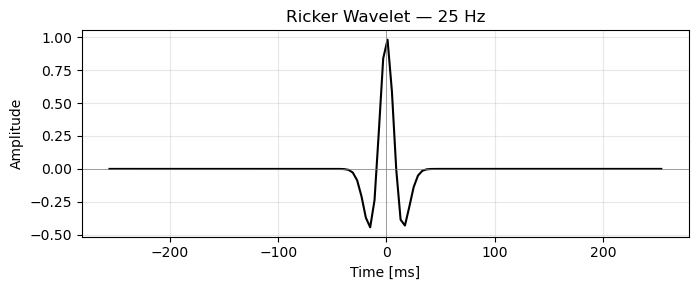

In [19]:
def ricker(f, length, dt):
    """Generate a zero-phase Ricker wavelet.

    Parameters
    ----------
    f      : float  — dominant frequency [Hz]
    length : float  — total duration [s]
    dt     : float  — sample interval [s]

    Returns
    -------
    t : ndarray  — time axis [s]
    w : ndarray  — wavelet amplitudes
    """
    n = int(length / dt)
    t = np.linspace(-length / 2, (length - dt) / 2, n)
    w = (1.0 - 2.0 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)
    return t, w


tw, w = ricker(f=25, length=0.512, dt=0.004)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tw * 1000, w, 'k', lw=1.5)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_title('Ricker Wavelet — 25 Hz')
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Amplitude')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 10.2 Synthetic seismogram

Convolve the reflection series with the wavelet:

$$synth(t) = RC(t) * w(t)$$

In [20]:
synth = np.convolve(RC_t, w, mode='same')

# ── Sanity check on array lengths ─────────────────────────────────────────────
print(f"Z      : {len(Z):,}  |  DEPTH  : {len(DEPTH):,}")
print(f"Z_t    : {len(Z_t):,}  |  t      : {len(t):,}")
print(f"RC_t   : {len(RC_t):,}  |  t[:-1] : {len(t[:-1]):,}")
print(f"synth  : {len(synth):,}  |  t[:-1] : {len(t[:-1]):,}")

Z      : 25,621  |  DEPTH  : 25,621
Z_t    : 750  |  t      : 750
RC_t   : 749  |  t[:-1] : 749
synth  : 749  |  t[:-1] : 749


### 10.3 Four-panel well-tie figure (time domain)

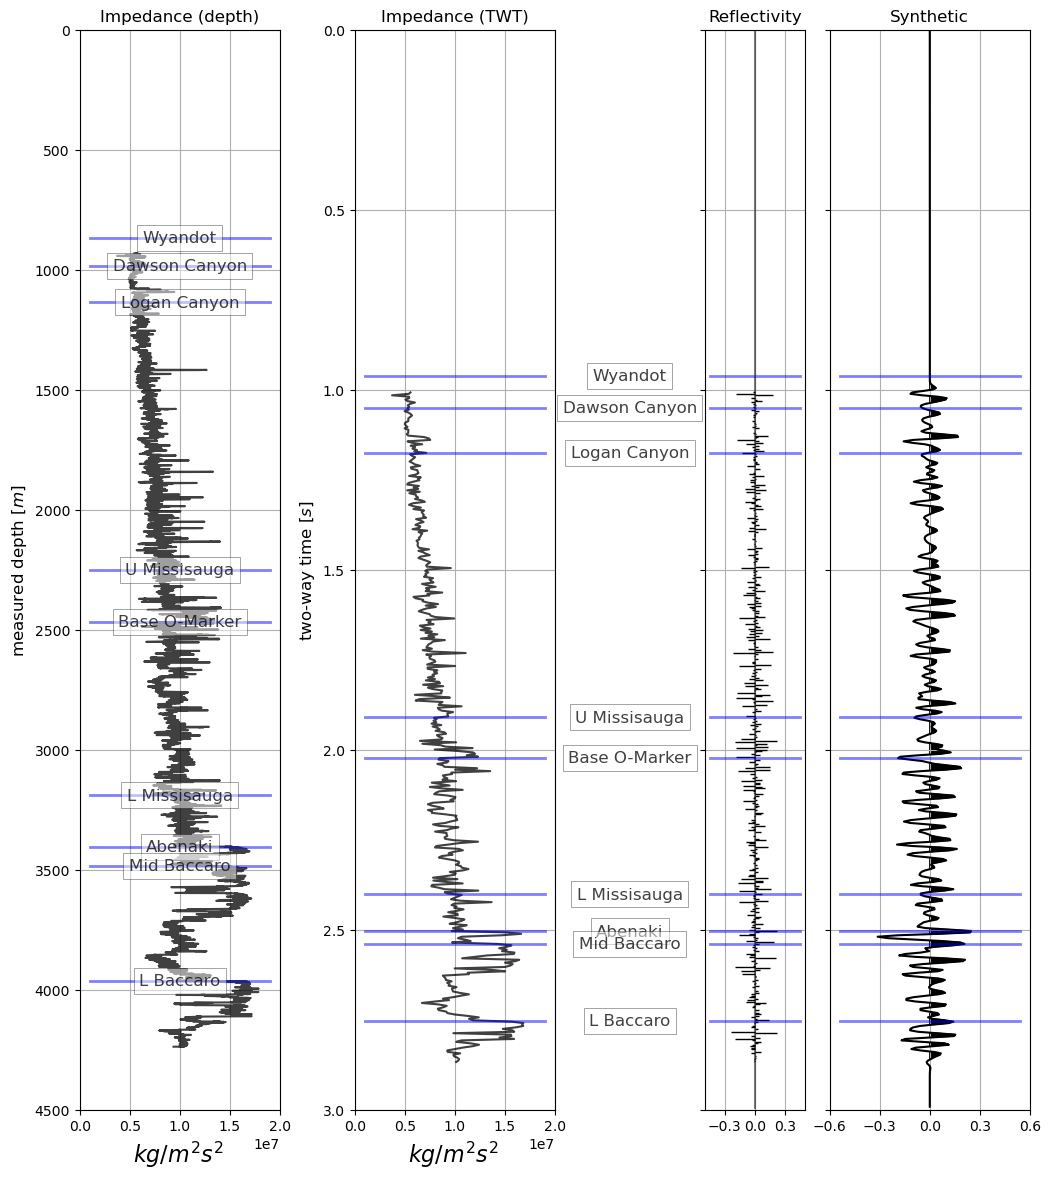

In [21]:
f2 = plt.figure(figsize=[10,12])

ax1 = f2.add_axes([0.05, 0.1, 0.2, 0.9])
ax1.plot(Z, DEPTH,'k', alpha=0.75)
ax1.set_title('Impedance (depth)')
ax1.set_ylabel('measured depth ' + '$[m]$', fontsize = '12' )
ax1.set_xlabel(r'$kg/m^2s^2$ ', fontsize = '16')
ax1.set_ylim(0, 4500)
ax1.set_xticks( [0.0e7, 0.5e7, 1.0e7, 1.5e7, 2.0e7 ] )
ax1.invert_yaxis()
ax1.grid()

ax2 = f2.add_axes([0.325, 0.1, 0.2, 0.9])
ax2.plot(Z_t, t,'k', alpha=0.75)
ax2.set_title('Impedance (TWT)')
ax2.set_ylabel('two-way time ' + '$[s]$', fontsize = '12' )
ax2.set_xlabel(r'$kg/m^2s^2$ ', fontsize = '16')
ax2.set_ylim(0, 3)
ax2.set_xticks( [0.0e7, 0.5e7, 1.0e7, 1.5e7, 2.0e7 ] )
ax2.invert_yaxis()
ax2.grid()

ax3 = f2.add_axes([0.675, 0.1, 0.1, 0.9])
ax3.hlines(t[:-1], 0, RC_t, color='k', lw = 1)                    # Stems
ax3.plot([0, 0], [t.min(), t.max()], '-', c='k', alpha = 0.5)     # Middle bar
ax3.set_title('Reflectivity')
ax3.set_xlabel('', fontsize = '10')
ax3.set_ylim(0, 3)
ax3.set_xlim(-0.5, 0.5)
ax3.invert_yaxis()
ax3.set_yticklabels('')
ax3.set_xticks([-0.3, 0, 0.3] )
ax3.grid()

ax4 = f2.add_axes([0.8, 0.1, 0.2, 0.9])
ax4.plot(synth, t[:-1],'k')
ax4.fill_betweenx(t[:-1], synth,  0,  synth > 0.0,  color='k', alpha = 1.0)
ax4.set_title('Synthetic')
ax4.set_xlabel('', fontsize = '10')
ax4.set_ylim(0, 3)
ax4.set_xlim(-0.05, 0.05)
ax4.invert_yaxis()
ax4.set_yticklabels('')
ax4.set_xticks([-0.6, -0.3, 0, 0.3, 0.6 ] )
ax4.grid()

for i in range(1):
    for top, depth in tops.items():
        f2.axes[i].axhline( y = float(depth), color = 'b', lw = 2, 
                            alpha = 0.5, xmin = 0.05, xmax = 0.95 )
        f2.axes[i].text( x = 1e7, y = float(depth)-0.015, s = top,
                         alpha=0.75, color='k',
                         fontsize = '12',
                         horizontalalignment = 'center',
                         verticalalignment = 'center',
                         bbox=dict(facecolor='white', alpha=0.5, lw = 0.5),
                         weight = 'light')
        

for i in range(1,4):
    for twt in tops_twt.values():
        f2.axes[i].axhline( y = float(twt), color = 'b', lw = 2, 
                    alpha = 0.5, xmin = 0.05, xmax = 0.95)
for i in range(1,2):
    for top, twt in tops_twt.items():
        f2.axes[i].text( x = 2.75e7, y = float(twt), s = top,
                         alpha=0.75, color='k',
                         fontsize = '12',
                         horizontalalignment = 'center',
                         verticalalignment = 'center',
                         bbox=dict(facecolor='white', alpha=0.5, lw = 0.5),
                         weight = 'light'
                         )

# 11. Comparison with Real Seismic Data

We load a 2-D inline section (Penobscot crossline 1155) stored as a text file.
The synthetic seismogram is plotted at the well location (trace 77 of 500) for
a visual well-tie quality check.

In [22]:
# ── Load seismic section ─────────────────────────────────────────────────────
traces_raw = np.loadtxt('./Input/PenobXL_1155.txt')

# Transpose and flip so rows = time samples, cols = traces
traces_64  = np.fliplr(np.transpose(traces_raw))
traces_16  = traces_64.astype(np.int16)    # cast to int16 to save memory

print(f"Section shape  : {traces_64.shape}  (time samples × traces)")
print(f"Memory — float64: {traces_64.nbytes/1e6:.1f} MB   int16: {traces_16.nbytes/1e6:.1f} MB")
print(f"float64 range  : [{traces_64.min():.1f}, {traces_64.max():.1f}]")
print(f"int16   range  : [{traces_16.min()}, {traces_16.max()}]")

# Use int16 for subsequent plotting
traces = traces_16
del traces_64, traces_16

Section shape  : (1003, 401)  (time samples × traces)
Memory — float64: 3.2 MB   int16: 0.8 MB
float64 range  : [-18392.0, 25210.0]
int16   range  : [-18392, 25210]


### 11.1 Well-tie figure with seismic section

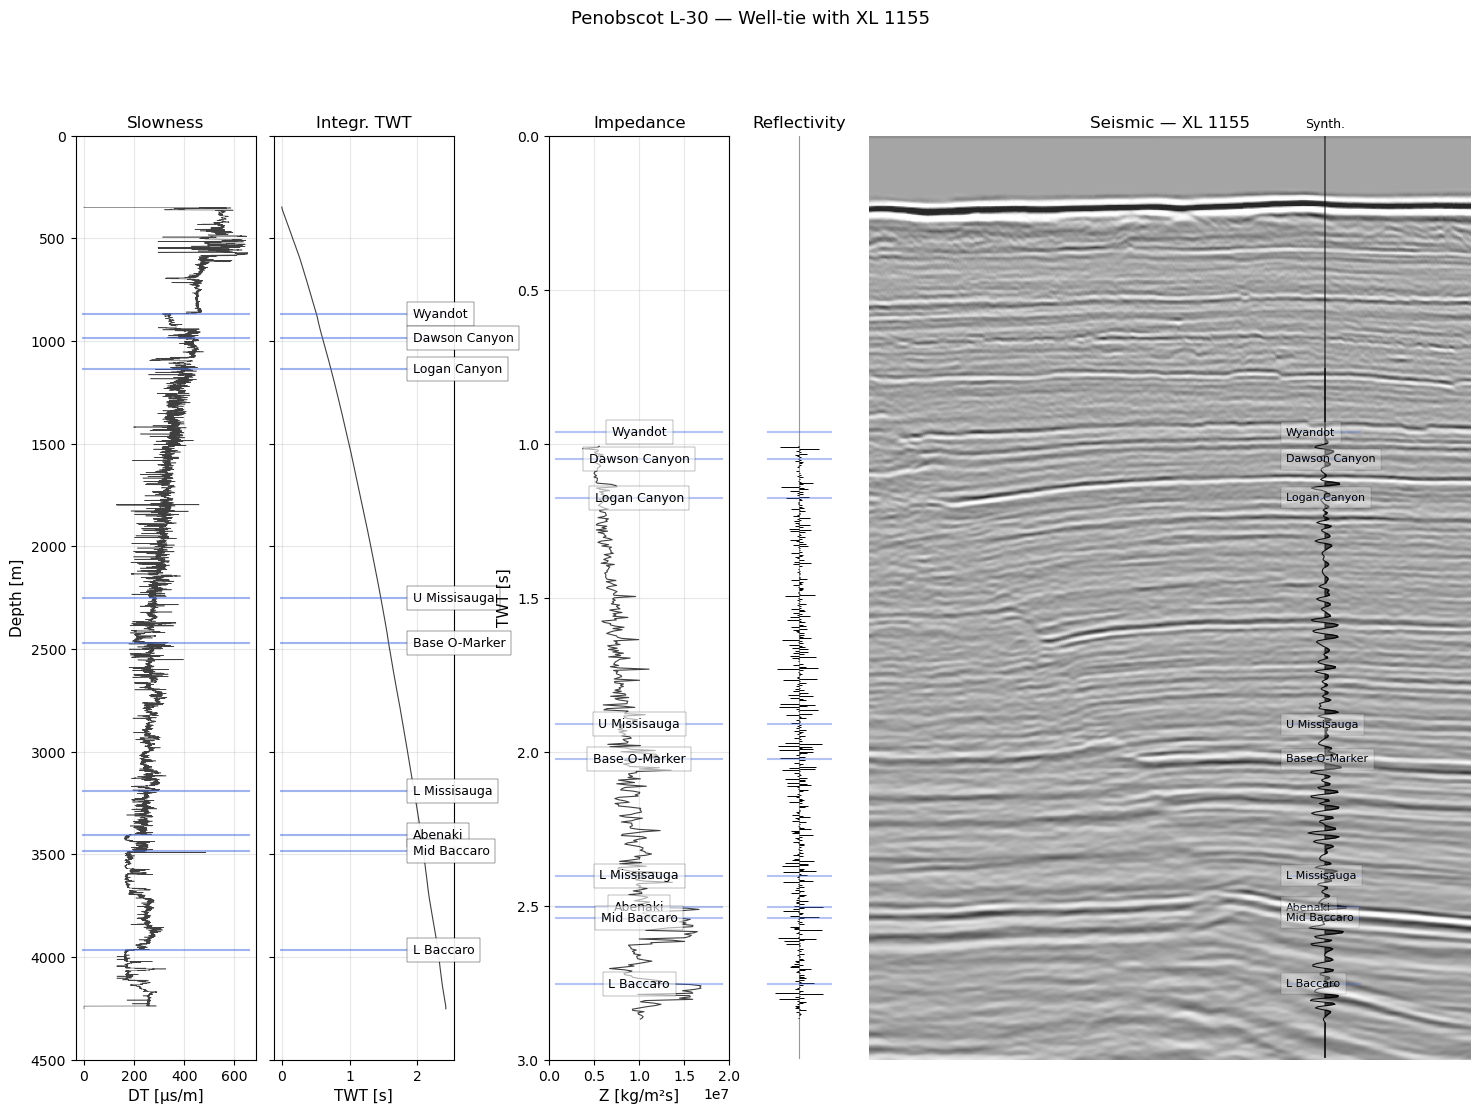

In [23]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(1, 6, width_ratios=[1.2, 1.2, 0.4, 1.2, 0.7, 4], wspace=0.08)

# ── Sonic (depth domain) ──────────────────────────────────────────────────────
axa = fig.add_subplot(gs[0])
axa.plot(DT, DEPTH, 'k', alpha=0.75, lw=0.4)
axa.set_title('Slowness')
axa.set_ylabel('Depth [m]', fontsize=11)
axa.set_xlabel('DT [μs/m]', fontsize=11)
axa.set_ylim(0, 4500)
axa.invert_yaxis()
axa.grid(alpha=0.3)

# ── Cumulative TWT (depth domain) ────────────────────────────────────────────
axb = fig.add_subplot(gs[1])
axb.plot(TCUM, DEPTH, 'k', alpha=0.75, lw=0.8)
axb.set_title('Integr. TWT')
axb.set_xlabel('TWT [s]', fontsize=11)
axb.set_ylim(4500, 0)
axb.set_yticklabels([])
axb.grid(alpha=0.3)

# Depth-domain tops
for name, depth in tops.items():
    for ax_ in [axa, axb]:
        ax_.axhline(y=depth, color='royalblue', lw=1.5, alpha=0.5, xmin=0.04, xmax=0.96)
    axb.text(x=TCUM.max() * 0.8, y=depth, s=name, fontsize=9, va='center',
             bbox=dict(facecolor='white', alpha=0.9, lw=0.3))

# ── White space separator ─────────────────────────────────────────────────────
axoff = fig.add_subplot(gs[2])
axoff.set_axis_off()

# ── Impedance (time domain) ───────────────────────────────────────────────────
axc = fig.add_subplot(gs[3])
axc.plot(Z_t, t, 'k', alpha=0.75, lw=0.8)
axc.set_title('Impedance')
axc.set_ylabel('TWT [s]', fontsize=11)
axc.set_xlabel('Z [kg/m²s]', fontsize=11)
axc.set_ylim(0, 3)
axc.set_xlim(0, 2e7)
axc.invert_yaxis()
axc.grid(alpha=0.3)

for name, twt in tops_twt.items():
    axc.axhline(y=twt, color='royalblue', lw=1.5, alpha=0.4, xmin=0.04, xmax=0.96)
    axc.text(x=1e7, y=twt, s=name, fontsize=9, va='center', ha='center',
             bbox=dict(facecolor='white', alpha=0.6, lw=0.3))

# ── Reflectivity ──────────────────────────────────────────────────────────────
axd = fig.add_subplot(gs[4])
axd.hlines(t[:-1], 0, RC_t, color='k', lw=0.7)
axd.plot([0, 0], [t.min(), t.max()], '-k', alpha=0.4, lw=0.8)
axd.set_title('Reflectivity')
axd.set_ylim(0, 3)
axd.set_xlim(-0.5, 0.5)
axd.invert_yaxis()
axd.set_yticklabels([])
axd.set_axis_off()
for twt in tops_twt.values():
    axd.axhline(y=twt, color='royalblue', lw=1.5, alpha=0.4, xmin=0.2, xmax=0.8)

# ── Seismic section ───────────────────────────────────────────────────────────
axe = fig.add_subplot(gs[5])
axe.imshow(traces[:750, 100:], cmap='Greys',
           vmin=-7000, vmax=7000, alpha=0.85, aspect='auto')
axe.set_axis_off()
axe.set_title('Seismic — XL 1155')

# ── Synthetic overlay on seismic ──────────────────────────────────────────────
bot = axe.get_position().get_points()[0][1]
top = axe.get_position().get_points()[1][1]
axf = fig.add_axes([0.795, bot, 0.048, top - bot])
axf.plot(synth, t[:-1], 'k', alpha=0.9, lw=0.8)
axf.fill_betweenx(t[:-1], synth, 0, where=synth > 0, color='k', alpha=0.6)
axf.set_title('Synth.', fontsize=9)
axf.set_ylim(0, 3)
axf.set_xlim(-0.5, 0.5)
axf.invert_yaxis()
axf.set_yticklabels([])
axf.set_axis_off()

for name, twt in tops_twt.items():
    axf.axhline(y=twt, color='royalblue', lw=1.5, alpha=0.3, xmin=0.1, xmax=0.9)
    axf.text(x=-0.45, y=twt, s=name, fontsize=8, va='center',
             bbox=dict(facecolor='white', alpha=0.3, lw=0.3))

fig.suptitle('Penobscot L-30 — Well-tie with XL 1155', y=0.985, fontsize=13)
plt.show()

# 12. Loading and Inspecting a 3-D SEG-Y Volume

We use Equinor's [`segyio`](https://github.com/equinor/segyio) library to read a curated
sub-volume of the **F3 Dip-steered Median** seismic attribute.

> *"Segyio is a small LGPL-licensed C library for easy interaction with SEG-Y formatted
> seismic data, with language bindings for Python and Matlab."*

**File:** `F3_Dip_steered_median_subvolume_IL230-430_XL475-675_T1600-1800.sgy`  
(Inlines 230–430, Crosslines 475–675, TWT 1600–1800 ms)

In [24]:
filename = ('./Input/F3_Dip_steered_median_subvolume_'
            'IL230-430_XL475-675_T1600-1800.sgy')

with segyio.open(filename) as s:
    print(f"Traces             : {s.tracecount:,}")
    print(f"Samples per trace  : {s.samples.size}")
    print(f"Sample interval    : {s.bin[segyio.BinField.Interval]} μs  "
          f"= {s.bin[segyio.BinField.Interval]/1e6:.3f} s")
    print(f"Inline range       : {s.ilines.min()} – {s.ilines.max()}")
    print(f"Crossline range    : {s.xlines.min()} – {s.xlines.max()}")
    c = segyio.cube(s)

print(f"\nCube shape         : {c.shape}  (inlines × xlines × time samples)")
print(f"Data type          : {c.dtype}")
print(f"Max |amplitude|    : {np.max(np.abs(c)):.2f}")
print(f"Min non-zero |amp| : {np.min(np.abs(c[np.nonzero(c)])):.6f}")

Traces             : 40,401
Samples per trace  : 51
Sample interval    : 4000 μs  = 0.004 s
Inline range       : 230 – 430
Crossline range    : 475 – 675

Cube shape         : (201, 201, 51)  (inlines × xlines × time samples)
Data type          : float32
Max |amplitude|    : 21683.00
Min non-zero |amp| : 1.000000


In [25]:
# Cast to int16 to halve memory usage
# NOTE: verify that max amplitude < 32767 (int16 range) before casting
assert np.max(np.abs(c)) < 32767, "Amplitude out of int16 range — cannot cast safely"
c = c.astype(np.int16)
print(f"Cube memory (int16): {c.nbytes/1e6:.1f} MB   shape: {c.shape}")

Cube memory (int16): 4.1 MB   shape: (201, 201, 51)


### 12.1 Amplitude distribution

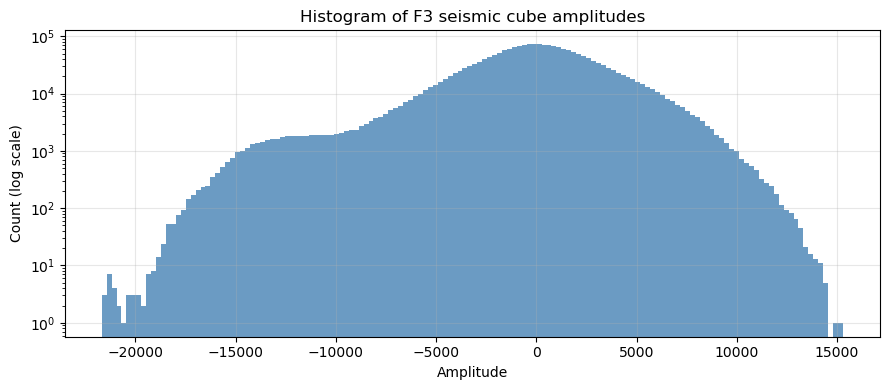

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(c.flatten(), bins=150, color='steelblue', alpha=0.8, edgecolor='none')
ax.set_yscale('log')
ax.set_title('Histogram of F3 seismic cube amplitudes')
ax.set_xlabel('Amplitude')
ax.set_ylabel('Count (log scale)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 12.2 Static slice views

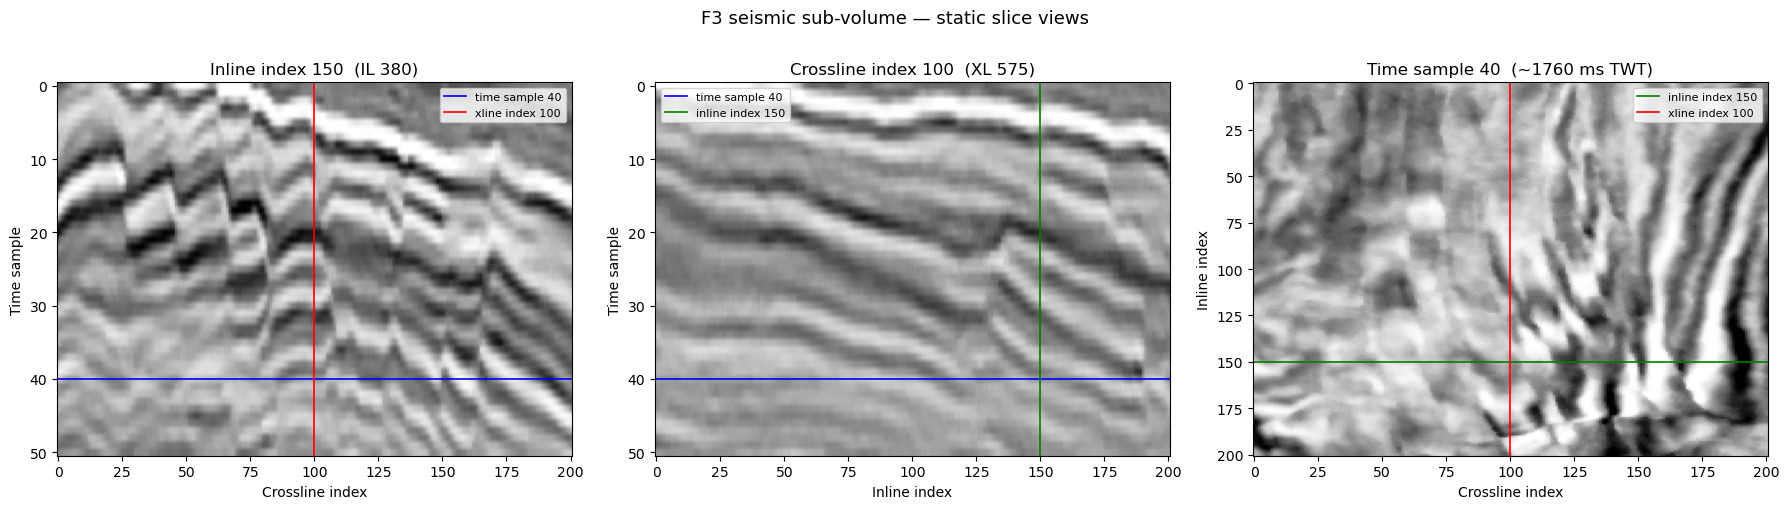

In [27]:
il_idx = 150   # inline index (0-based within sub-volume)
xl_idx = 100   # crossline index
ts_idx = 40    # time-sample index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def clip_amp(data, pct=98):
    """Symmetric clip at the given percentile."""
    ma = np.percentile(np.abs(data), pct)
    return -ma, ma

# ── inline slice ──────────────────────────────────────────────────────────────
vmin, vmax = clip_amp(c[il_idx, :, :])
axes[0].imshow(c[il_idx, :, :].T, vmin=vmin, vmax=vmax, cmap='Greys', aspect='auto')
axes[0].set_title(f'Inline index {il_idx}  (IL {230 + il_idx})')
axes[0].set_xlabel('Crossline index')
axes[0].set_ylabel('Time sample')
axes[0].axhline(y=ts_idx, color='b', lw=1.2, label=f'time sample {ts_idx}')
axes[0].axvline(x=xl_idx, color='r', lw=1.2, label=f'xline index {xl_idx}')
axes[0].legend(fontsize=8)

# ── crossline slice ───────────────────────────────────────────────────────────
vmin, vmax = clip_amp(c[:, xl_idx, :])
axes[1].imshow(c[:, xl_idx, :].T, vmin=vmin, vmax=vmax, cmap='Greys', aspect='auto')
axes[1].set_title(f'Crossline index {xl_idx}  (XL {475 + xl_idx})')
axes[1].set_xlabel('Inline index')
axes[1].set_ylabel('Time sample')
axes[1].axhline(y=ts_idx, color='b', lw=1.2, label=f'time sample {ts_idx}')
axes[1].axvline(x=il_idx, color='g', lw=1.2, label=f'inline index {il_idx}')
axes[1].legend(fontsize=8)

# ── time slice ────────────────────────────────────────────────────────────────
vmin, vmax = clip_amp(c[:, :, ts_idx])
axes[2].imshow(c[:, :, ts_idx], vmin=vmin, vmax=vmax, cmap='Greys', aspect='auto')
axes[2].set_title(f'Time sample {ts_idx}  (~{1600 + ts_idx * 4} ms TWT)')
axes[2].set_xlabel('Crossline index')
axes[2].set_ylabel('Inline index')
axes[2].axhline(y=il_idx, color='g', lw=1.2, label=f'inline index {il_idx}')
axes[2].axvline(x=xl_idx, color='r', lw=1.2, label=f'xline index {xl_idx}')
axes[2].legend(fontsize=8)

plt.suptitle('F3 seismic sub-volume — static slice views', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# 13. Interactive 3-D Volume Browser

Use the sliders to scan through the three orthogonal slice orientations simultaneously.
Coloured lines show where each slice intersects the other two.

> **Note:** `continuous_update=True` re-renders on every slider tick.  
> Set it to `False` if your machine is slow.

In [28]:
def load_seismic(filepath):
    """Load a SEG-Y file as a NumPy array (int16)."""
    with segyio.open(filepath) as s:
        return segyio.cube(s).astype(np.int16)


def seismic_browser(colormap, inline, xline, timeslice, volume):
    """Plot three orthogonal slices through a seismic cube.

    Parameters are controlled by ipywidgets sliders.
    """
    vol = load_seismic(volume)
    ma  = np.percentile(vol, 98)

    fig, axes = plt.subplots(3, 1, figsize=(15, 17))
    kw = dict(vmin=-ma, vmax=ma, cmap=colormap, aspect='auto')

    # ── inline ────────────────────────────────────────────────────────────────
    axes[0].imshow(vol[inline, :, :].T, **kw)
    axes[0].set_title(f'Inline {inline}', color='tomato', fontsize=12)
    axes[0].set_xlabel('Crossline index')
    axes[0].set_ylabel('Time sample')
    axes[0].axhline(y=timeslice, color='royalblue',  lw=1.5, label='time slice')
    axes[0].axvline(x=xline,    color='seagreen',    lw=1.5, label='crossline')
    axes[0].legend(fontsize=9)

    # ── crossline ─────────────────────────────────────────────────────────────
    axes[1].imshow(vol[:, xline, :].T, **kw)
    axes[1].set_title(f'Crossline {xline}', color='seagreen', fontsize=12)
    axes[1].set_xlabel('Inline index')
    axes[1].set_ylabel('Time sample')
    axes[1].axhline(y=timeslice, color='royalblue', lw=1.5, label='time slice')
    axes[1].axvline(x=inline,   color='tomato',     lw=1.5, label='inline')
    axes[1].legend(fontsize=9)

    # ── time slice ────────────────────────────────────────────────────────────
    axes[2].imshow(vol[:, :, timeslice], **kw)
    axes[2].set_title(f'Time sample {timeslice}', color='royalblue', fontsize=12)
    axes[2].set_xlabel('Crossline index')
    axes[2].set_ylabel('Inline index')
    axes[2].axhline(y=inline, color='tomato',  lw=1.5, label='inline')
    axes[2].axvline(x=xline,  color='seagreen',lw=1.5, label='crossline')
    axes[2].legend(fontsize=9)

    fig.colorbar(axes[2].images[0], ax=axes.ravel().tolist(),
                 shrink=0.35, label='Amplitude')
    fig.suptitle('F3 seismic cube — interactive browser', fontsize=14, y=0.995)
    plt.show()


_n_il = c.shape[0] - 1
_n_xl = c.shape[1] - 1
_n_ts = c.shape[2] - 1

interact(
    seismic_browser,
    colormap   = widgets.Dropdown(
        options=['Greys', 'Greys_r', 'seismic', 'seismic_r', 'RdBu_r',
                 'viridis', 'plasma', 'inferno'],
        value='Greys', description='Colormap'),
    inline     = widgets.IntSlider(
        value=100, min=0, max=_n_il, step=1, continuous_update=True,
        description='Inline', style={'description_width': 'initial'}),
    xline      = widgets.IntSlider(
        value=100, min=0, max=_n_xl, step=1, continuous_update=True,
        description='Crossline', style={'description_width': 'initial'}),
    timeslice  = widgets.IntSlider(
        value=25,  min=0, max=_n_ts, step=1, continuous_update=True,
        description='Time sample', style={'description_width': 'initial'}),
    volume     = widgets.fixed(filename),
);

interactive(children=(Dropdown(description='Colormap', options=('Greys', 'Greys_r', 'seismic', 'seismic_r', 'R…

---
# 14. Summary

In this session we covered the full well-tie workflow:

1. **Loaded** a LAS file and converted log curves to SI units.
2. **Corrected** for the shallow section (water column + replacement interval) to compute
   the absolute TWT at the top of the sonic log.
3. **Despiked** the RHOB and DT logs using a rolling-median filter.
4. **Computed** acoustic impedance *Z* and the depth-domain reflection coefficient series *RC*.
5. **Loaded** well tops and converted them to the time domain via the TDR.
6. **Visualised** the log cascade in the depth domain.
7. **Resampled** logs to seismic sample rate (4 ms) and computed *RC(t)*.
8. **Convolved** *RC(t)* with a 25 Hz Ricker wavelet to create a synthetic seismogram.
9. **Compared** the synthetic with a real seismic section (Penobscot XL 1155).
10. **Loaded** a 3-D SEG-Y volume (F3 Dip-steered Median) and explored it with
    static slices and an interactive volume browser.

**Key Python tools:** `lasio`, `segyio`, `numpy`, `matplotlib`, `ipywidgets`
